# This notebook performs an FSSH simulation using medium electronic coupling to examine the influence of increased coupling on electronic population transfer and nuclear motion.

In [1]:
import sys
import cmath
import math
import os
import h5py
import matplotlib.pyplot as plt   # plots
import numpy as np
import time
import warnings

from liblibra_core import *
import util.libutil as comn
from libra_py import units
import libra_py.models.Holstein as Holstein
import libra_py.models.Morse as Morse
import libra_py.models.Zhu as Zhu
import libra_py.models.Esch_Levine as Esch_Levine
from libra_py import dynamics_plotting
import libra_py.dynamics.tsh.compute as tsh_dynamics
import libra_py.dynamics.tsh.plot as tsh_dynamics_plot
import libra_py.data_savers as data_savers


from recipes import ehrenfest_adi_nac, ehrenfest_adi_ld, ehrenfest_dia
from recipes import fssh, fssh_ssy, gfsh, gfsh_ssy, mssh, mssh_ssy, bcsh, bcsh_ssy
from recipes import ida, ida_ssy, sdm, sdm_ssy
from recipes import dish, dish_rev2023
from recipes import mfsd
from recipes import shxf
from recipes import fssh2, fssh3
from recipes import mash

#from matplotlib.mlab import griddata
#%matplotlib inline 
warnings.filterwarnings('ignore')

colors = {}
colors.update({"11": "#8b1a0e"})  # red       
colors.update({"12": "#FF4500"})  # orangered 
colors.update({"13": "#B22222"})  # firebrick 
colors.update({"14": "#DC143C"})  # crimson   
colors.update({"21": "#5e9c36"})  # green
colors.update({"22": "#006400"})  # darkgreen  
colors.update({"23": "#228B22"})  # forestgreen
colors.update({"24": "#808000"})  # olive      
colors.update({"31": "#8A2BE2"})  # blueviolet
colors.update({"32": "#00008B"})  # darkblue  
colors.update({"41": "#2F4F4F"})  # darkslategray

clrs_index = ["11", "21", "31", "41", "12", "22", "32", "13","23", "14", "24"]

<frozen importlib._bootstrap>:241: RuntimeWarning: to-Python converter for std::vector<std::vector<int, std::allocator<int> >, std::allocator<std::vector<int, std::allocator<int> > > > already registered; second conversion method ignored.
<frozen importlib._bootstrap>:241: RuntimeWarning: to-Python converter for boost::python::detail::container_element<std::vector<std::vector<int, std::allocator<int> >, std::allocator<std::vector<int, std::allocator<int> > > >, unsigned long, boost::python::detail::final_vector_derived_policies<std::vector<std::vector<int, std::allocator<int> >, std::allocator<std::vector<int, std::allocator<int> > > >, false> > already registered; second conversion method ignored.
<frozen importlib._bootstrap>:241: RuntimeWarning: to-Python converter for std::vector<std::vector<float, std::allocator<float> >, std::allocator<std::vector<float, std::allocator<float> > > > already registered; second conversion method ignored.
<frozen importlib._bootstrap>:241: RuntimeWar

#  Model Hamiltonians

In [2]:
def compute_model(q, params, full_id):

    model = params["model"]
    res = None
    
    if model==1:        
        res = Holstein.Holstein2(q, params, full_id) 
    elif model==2:
        res = Esch_Levine.JCP_2020(q, params, full_id)        
    elif model==3:
        res = Morse.general(q, params, full_id)
    else:
        pass #res = compute_model_nbra_files(q, params, full_id)            

    return res

Define several sets of parameters for Holstein Hamiltonian.

Here, we define several sets of parameters:

* Sets 1 to 4 - for the 2-level Holstein Hamiltonians. These are just parabolas with constant coupling.
* Sets 5 to 8 - for the n-level Esch-Levine Hamiltonians. These are just lines or bundles of lines crossing with yet another line and having a constant coupling. These models are for 2- to 5-state problems
* Sets 9 to 11 - for the 3-level problems, which are the Morse potentials with non-constant coupling. The parameters are loaded to be those use by Coronado, Xing, and Miller. 

<a name="set_Coronado_Xing_Miller_params-1"></a>

In [3]:
model_params1 = {"model":1, "model0":1, "nstates":2, "E_n":[0.0,  0.0], "x_n":[0.0,  2.5],"k_n":[0.002, 0.005],"V":0.000}
model_params2 = {"model":1, "model0":1, "nstates":2, "E_n":[0.0,  0.0], "x_n":[0.0,  2.5],"k_n":[0.002, 0.005],"V":0.001}
model_params3 = {"model":1, "model0":1, "nstates":2, "E_n":[0.0,  0.0], "x_n":[0.0,  2.5],"k_n":[0.002, 0.005],"V":0.01}
model_params4 = {"model":1, "model0":1, "nstates":2, "E_n":[0.0, -0.01], "x_n":[0.0,  0.5],"k_n":[0.002, 0.008],"V":0.001}

model_params5 = {"model":2, "model0":2, "nstates":2, 
                 "w0":0.015, "w1":0.005, "V":0.005, "eps":0.0, "i_crit":2, "delta":0.01 } # Esch-Levine

model_params6 = {"model":2, "model0":2, "nstates":3, 
                 "w0":0.015, "w1":0.005, "V":0.005, "eps":0.0, "i_crit":3, "delta":0.01 } # Esch-Levine

model_params7 = {"model":2, "model0":2, "nstates":5, 
                 "w0":0.015, "w1":0.005, "V":0.005, "eps":0.0, "i_crit":4, "delta":0.01 } # Esch-Levine

model_params8 = {"model":2, "model0":2, "nstates":5, 
                 "w0":0.015, "w1":0.005, "V":0.005, "eps":0.02, "i_crit":3, "delta":0.01 } # Esch-Levine

model_params9 = {"model":3, "model0":3, "nstates":3}; Morse.set_Coronado_Xing_Miller_params(model_params9, 1)
model_params10 = {"model":3, "model0":3, "nstates":3}; Morse.set_Coronado_Xing_Miller_params(model_params10, 2)
model_params11 = {"model":3, "model0":3, "nstates":3}; Morse.set_Coronado_Xing_Miller_params(model_params11, 3)


all_model_params = [model_params1, model_params2, model_params3, model_params4, 
                    model_params5, model_params6, model_params7, model_params8,
                    model_params9, model_params10
                   ]

# Visualize models. 

In [4]:
# New plotting:
# Common setups
plot_params = {"figsize":[24, 6], "titlesize":24, "labelsize":28, "fontsize": 28, "xticksize":26, "yticksize":26,
               "colors": colors, "clrs_index": clrs_index,
               "prefix":F"case", "save_figures":0, "do_show":1,
               "plotting_option":1, "nac_idof":0 }

The next model, Model 2 adds a non-zero and rather small diabatic coupling, so that the surfaces do interact, but the splitting between the adiabatic surfaces is small, hence large NAC

<Figure size 640x480 with 0 Axes>

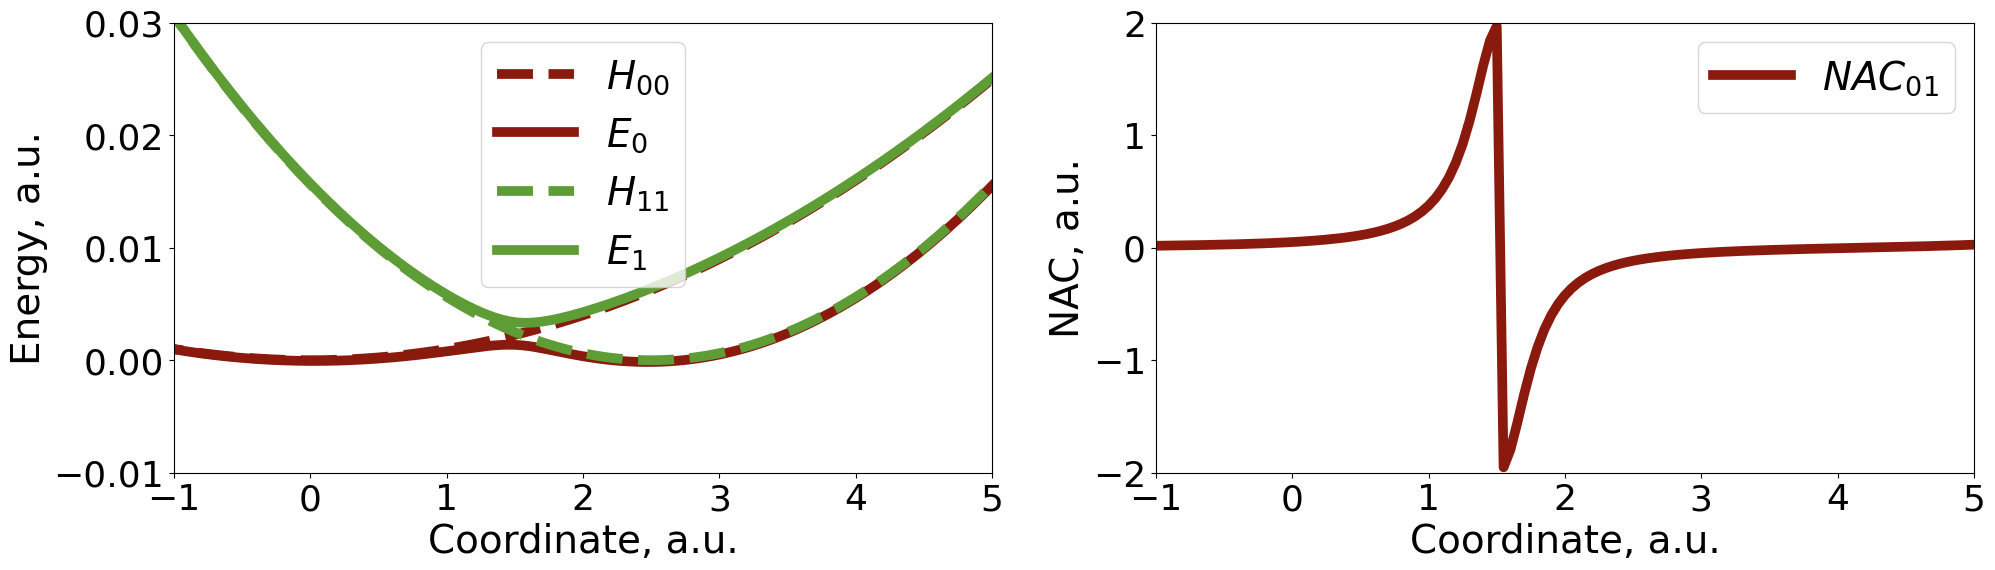

In [5]:
# Model 2
plot_params.update( { "xlim":[-1, 5], "ylim":[-0.01, 0.03], "ylim2":[-2, 2], "show_nac_abs":0 })
dynamics_plotting.plot_surfaces(compute_model, [ model_params2 ], [0, 1], -4.0, 5.0, 0.05, plot_params)

# Choose the model

In [6]:
# 0 - Holstein, trivial crossing, 2 level
# 1 - Holstein, strong nonadiabatic, 2 level
# 2 - Holstein, adiabatic, 2 level
# 3 - Holstein, double crossing, strong nonadiabatic, 2 level
# 4 - Esch-Levine, LZ-like, 2 level
# 5 - Esch-Levine, 1 crosses 2 parallel, 3 level
# 6 - Esch-Levine, 1 crosses 4 evenly-spaced parallel, 5 level
# 7 - Esch-Levine, 1 crosses 4 parallel split into 2 groups, 5 level
# 8 - Morse 1, 3-level
# 9 - Morse 2, 3-level
# 10 - Morse 3, 3-level

#################################
# Give the model used an index
model_indx = 1
################################

model_params = all_model_params[model_indx]

# Simulation Parameters

- **nsteps** – Number of nuclear dynamics time steps.
- **ntraj** – Number of independent trajectories.
- **nstates** – Number of electronic states in the model.
- **dt** – Nuclear integration time step (atomic units).
- **num_electronic_substeps** – Number of electronic propagation steps per nuclear step.
- **isNBRA / is_nbra** – Set to 1 for NBRA calculations; 0 for standard nonadiabatic dynamics.
- **progress_frequency** – Frequency for printing simulation progress.
- **which_adi_states** – Adiabatic states whose properties are saved.
- **which_dia_states** – Diabatic states whose properties are saved.
- **mem_output_level** – Controls the amount of output written to the HDF5 file.
- **properties_to_save** – List of physical quantities saved during the simulation (e.g., populations, energies, coordinates, and momenta).

In [7]:
NSTATES = model_params["nstates"]

dyn_general = { "nsteps":2500, "ntraj":25, "nstates":NSTATES,
                "dt":10.0, "num_electronic_substeps":1, "isNBRA":0, "is_nbra":0,
                "progress_frequency":0.1, "which_adi_states":range(NSTATES), "which_dia_states":range(NSTATES),      
                "mem_output_level":3,
                "properties_to_save":[ "timestep", "time", "q", "p", "f", "Cadi", "Cdia", "Epot_ave", "Ekin_ave", "Etot_ave",
                "se_pop_adi", "se_pop_dia", "sh_pop_adi", "sh_pop_dia", "mash_pop_adi", "mash_pop_dia"],
                "prefix":"adiabatic_md", "prefix2":"adiabatic_md"
              }

#[ "timestep", "time", "q", "p", "f", "Cadi", "Cdia", "Epot_ave", "Ekin_ave", "Etot_ave",
#                "se_pop_adi", "se_pop_dia", "sh_pop_adi", "hvib_adi", "hvib_dia", "St", "basis_transform", "D_adi" ]

# Method

In [8]:
#################################
# Give the recipe above an index
method_indx = 4
#################################

if method_indx == 0:
    ehrenfest_dia.load(dyn_general)  # Ehrenfest, dia
elif method_indx == 1:
    ehrenfest_adi_nac.load(dyn_general)  # Ehrenfest, adi with NACs    
elif method_indx == 2:
    ehrenfest_adi_ld.load(dyn_general)  # Ehrenfest, adi with LD
elif method_indx == 3:
    mfsd.load(dyn_general)  # MFSD

elif method_indx == 4:
    fssh.load(dyn_general)  # FSSH
elif method_indx == 5:
    fssh_ssy.load(dyn_general)  # FSSH + SSY
elif method_indx == 6:
    gfsh.load(dyn_general)  # GFSH
elif method_indx == 7:
    gfsh_ssy.load(dyn_general)  # GFSH + SSY
elif method_indx == 8:
    mssh.load(dyn_general)  # MSSH
elif method_indx == 9:
    mssh_ssy.load(dyn_general)  # MSSH + SSY    

elif method_indx == 10:
    bcsh.load(dyn_general)  # BCSH    
elif method_indx == 11:
    bcsh_ssy.load(dyn_general)  # BCSH + SSY
elif method_indx == 12:
    sdm.load(dyn_general)  # SDM with default EDC parameters
elif method_indx == 13:
    sdm_ssy.load(dyn_general)  # SDM with default EDC parameters + SSY
elif method_indx == 14:
    ida.load(dyn_general)  # IDA
elif method_indx == 15:
    ida_ssy.load(dyn_general)  # IDA + SSY
elif method_indx == 16:
    dish.load(dyn_general)  # DISH with default EDC parameters 
elif method_indx == 17:
    dish.load(dyn_general)  # DISH with IPSD decoherence rates
    dyn_general.update({"decoherence_times_type":3}) # Schwartz 2 decoherence times
elif method_indx == 18:
    sdm.load(dyn_general)  # SDM with IPSD decoherence rates
    dyn_general.update({"decoherence_times_type":3}) # Schwartz 2 decoherence times
elif method_indx == 19:
    sdm_ssy.load(dyn_general)  # SDM with IPSD decoherence rates + SSY
    dyn_general.update({"decoherence_times_type":3}) # Schwartz 2 decoherence times
elif method_indx == 20:
    shxf.load(dyn_general)  # SHXF
    
elif method_indx == 21:    
    dish_rev2023.load(dyn_general)  # DISH, rev2023, based on TSH trajectories
    dyn_general.update({"decoherence_times_type":0}) # manual decoherence times

    r = 1e-3
    nst = model_params["nstates"]
    A = MATRIX(nst,nst)
    for i in range(nst):
        for j in range(i+1, nst):
            A.set(i,j, r)
            A.set(j,i, r)
    dyn_general.update( { "decoherence_rates":A } )  # Manual decoherence rates

elif method_indx == 22:    
    fssh2.load(dyn_general)  # FSSH2

elif method_indx == 23:
    fssh3.load(dyn_general)  # FSSH3

elif method_indx == 24:
    mash.load(dyn_general)  # MASH
    
# This needs to be set up here, but since we are going to consider different sets of such parameters,
# we will comment this section here and re-define it below
#if method_indx in [3, 17, 18, 19]:
#    A = MATRIX(NSTATES, NSTATES)
#    for i in range(NSTATES):
#        A.set(i,i, 10.0)
#    dyn_general.update({"schwartz_decoherence_inv_alpha":A})    

## Surface Hopping Variants

The following settings define how the FSSH algorithm handles attempted surface hops, including the hop acceptance criterion and the rescaling of nuclear momenta after a successful hop. In this work, the default FSSH settings (variant_indx = 0) are used.

In [9]:
#################################
# Adds ways of hop acceptance/velocity rescaling, only for some methods
# vary this only for methods: [4 - 16]
variant_indx = 0
#################################

if method_indx in [0, 1, 2, 3]:
    variant_indx = 0 # use default settings
else:
    pass

suff = ""
if variant_indx == 0:
    # This is already a default behavior 
    #dyn_general.update({"hop_acceptance_algo":10, "momenta_rescaling_algo":101 }) 
    suff = "v-" # accept and rescale based on total energy, reverse on frustrated    
elif variant_indx == 1:
    dyn_general.update({"hop_acceptance_algo":10, "momenta_rescaling_algo":100 })  
    suff = "v+" # accept and rescale based on total energy, do not reverse on frustrated
elif variant_indx == 2:    
    dyn_general.update({"hop_acceptance_algo":20, "momenta_rescaling_algo":200 })  
    suff = "h-" # accept and rescale based on NAC vectors, do not reverse on frustrated
elif variant_indx == 3:        
    dyn_general.update({"hop_acceptance_algo":20, "momenta_rescaling_algo":201 })  
    suff = "h+" # accept and rescale based on NAC vectors, reverse on frustrated
elif variant_indx == 4:    
    dyn_general.update({"hop_acceptance_algo":21, "momenta_rescaling_algo":200 })  
    suff = "g-" # accept and rescale based on force differences, do not reverse on frustrated
elif variant_indx == 5:
    dyn_general.update({"hop_acceptance_algo":21, "momenta_rescaling_algo":201 })  
    suff = "g+" # accept and rescale based on force differences, reverse on frustrated

## Method-Specific Parameters:
Additional parameters are required only for selected nonadiabatic dynamics methods (e.g., Schwartz, SDM, and SHXF). Since the standard FSSH method (method_indx = 4) is used in this work, no additional method-specific parameters were applied.

In [10]:
#################################
# Adds variations of the parameter
param_indx = 1
#################################

if method_indx in [3, 17, 18, 19]:
    if param_indx == 0:
        val = 0.1
    elif param_indx == 1:
        val = 1.0
    elif param_indx == 2:
        val = 10.0 
    elif param_indx == 3:
        val = 100.0
    
    A = MATRIX(NSTATES, NSTATES)
    for i in range(NSTATES):
        A.set(i,i, val)
    dyn_general.update({"schwartz_decoherence_inv_alpha":A})
elif method_indx in [20]:
    param_indx = 0
    wp_width = MATRIX(1,1); wp_width.set(0,0,0.3)
    dyn_general.update({"wp_width": wp_width})
else:
    param_indx = 0

# Initial Conditions 
## For Nuclear and Electronic Degrees of Freedom

This cell defines the initial nuclear coordinates, momenta, and electronic state populations before the surface hopping simulation begins. It also selects whether these quantities are fixed or sampled from a distribution.

* `ndof` - number of nuclear degrees of freedom
* `q` - nuclear coordinates, should be of length `ndof`
* `p` - nuclear momenta, should be of length `ndof`
* `mass` - nuclear masses, should be of length `ndof`
* `force_constant` - should be of length `ndof`; this is the force constant of the harmonic potential that defines the width of the Gaussian wavepacket (that is the ground-state solution for such potential)
* `init_type` - how to sample (or not) momenta and coordinates

For electronic variables:
* `ndia` - the number of diabatic states
* `nadi` - the number of adiabatic states
* `rep` - representation in which we initialize the electronic variables:
  - 0 - diabatic wfc;
  - 1 - adiabatic wfc;
  - 2 - diabatic density matrix;
  - 3 - adiabatic density matrix;
* `istates` - the populations of all `rep` states, should be of length `nadi`
* `init_type` - how to sample amplitudes

In [11]:
#*********************** This is for the initial condition type **************************
#============== How nuclear DOFs are initialized =================
#icond_nucl = 0  # Coords and momenta are set exactly to the given value
#icond_nucl = 1  # Coords are set, momenta are sampled
#icond_nucl = 2  # Coords are sampled, momenta are set
icond_nucl = 3  # Both coords and momenta are sampled

nucl_params = { "ndof":1, "q":[-4.0], "p":[0.0], 
                "mass":[2000.0], "force_constant":[0.01], 
                "init_type":icond_nucl }

#============= How electronic DOFs are initialized ==================
#icond_elec = 2  # amplitudes all have the same phase
icond_elec = 3  # amplitudes gain random phase 
#icond_elec = 4   # MASH sampling
if method_indx in [24]:  # MASH
    icond_elec = 4

#============= Also select the representation ========================
# rep = 0 # diabatic wfc
rep = 1 # adiabatic wfc

istates = []
for i in range(NSTATES):
    istates.append(0.0)    
    
elec_params = {"verbosity":2, "init_dm_type":0,
               "ndia":NSTATES, "nadi":NSTATES, 
               "rep":rep, "init_type":icond_elec, "istates":istates
              }

#============== This computes the enumerated index of the initial condition =============
icond_type_indx = rep * 8 + (icond_elec-2)*4 + icond_nucl


#******************** This is for specific values in initial conditions *******************
#####################################
# Select a specific initial condition
icond_indx = 0
#####################################    

if model_indx in [0, 1]: # Holstein model
    if icond_indx==0:
        nucl_params["q"] = [-4.0]
        elec_params["istates"][0] = 1.0          
    elif icond_indx==1:
        nucl_params["q"] = [-1.0]
        elec_params["istates"][1] = 1.0 
elif model_indx in [2]: # Holstein model
    if icond_indx==0:
        nucl_params["q"] = [-4.0]
        elec_params["istates"][0] = 1.0          
    elif icond_indx==1:
        nucl_params["q"] = [-2.0]
        elec_params["istates"][1] = 1.0 
elif model_indx in [3]: # Holstein model
    if icond_indx==0:
        nucl_params["q"] = [-4.0]
        elec_params["istates"][0] = 1.0          
    elif icond_indx==1:
        nucl_params["q"] = [-3.0]
        elec_params["istates"][1] = 1.0 
elif model_indx in [4]: # Esch-Levine 2-level
    if icond_indx==0:
        nucl_params["q"] = [-3.0]
        elec_params["istates"][1] = 1.0          
elif model_indx in [5]: # Esch-Levine 3-level
    if icond_indx==0:
        nucl_params["q"] = [-3.0]
        elec_params["istates"][2] = 1.0          
elif model_indx in [6,7]: # Esch-Levine 5-level, two types
    if icond_indx==0:
        nucl_params["q"] = [-3.0]
        elec_params["istates"][4] = 1.0          
elif model_indx in [8,9,10]: # Morse models
    if icond_indx==0:
        nucl_params["q"] = [2.0]
        elec_params["istates"][0] = 1.0

# Running the FSSH Dynamics
This cell combines the selected model, FSSH settings, and initial conditions, then runs the nonadiabatic dynamics simulation.  The calculation propagates an ensemble of nuclear trajectories while allowing stochastic hops between adiabatic electronic states.

In [12]:
%%time

dyn_params = dict(dyn_general)
dyn_params.update({ "prefix":F"model{model_indx}-method{method_indx}-variant_{suff}-param{param_indx}-icond_type{icond_type_indx}-icond{icond_indx}", 
                    "prefix2":F"model{model_indx}-method{method_indx}-variant_{suff}-param{param_indx}-icond_type{icond_type_indx}-icond{icond_indx}" })

print(F"Computing model{model_indx}-method{method_indx}-variant_{suff}-param{param_indx}-icond_type{icond_type_indx}-icond{icond_indx}")    

rnd = Random()
res = tsh_dynamics.generic_recipe(dyn_params, compute_model, model_params, elec_params, nucl_params, rnd)

Computing model1-method4-variant_v--param0-icond_type15-icond0
Active states (adiabatic)
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
Initial adiabatic populations
[1.0, 0.0]
======= Initialization type is 3 ========
setting representation 1 coefficients C_i for all i to complex numbers such that |C_i|^2  = target populations 
======= Initialization type is 3 ========
setting representation 1 coefficients C_i for all i to complex numbers such that |C_i|^2  = target populations 
======= Initialization type is 3 ========
setting representation 1 coefficients C_i for all i to complex numbers such that |C_i|^2  = target populations 
======= Initialization type is 3 ========
setting representation 1 coefficients C_i for all i to complex numbers such that |C_i|^2  = target populations 
======= Initialization type is 3 ========
setting representation 1 coefficients C_i for all i to complex numbers such that |C_i|^2  = target populations 
======= Initialization t

 step= 250
 step= 500
 step= 750
 step= 1000
 step= 1250
 step= 1500
 step= 1750
 step= 2000
 step= 2250
In mem_saver.save_data()
data_name =  ['timestep', 'time', 'q', 'p', 'f', 'Cadi', 'Cdia', 'Epot_ave', 'Ekin_ave', 'Etot_ave', 'se_pop_adi', 'se_pop_dia', 'sh_pop_adi', 'sh_pop_dia', 'mash_pop_adi', 'mash_pop_dia']
keywords =  ['timestep', 'time', 'q', 'p', 'f', 'Cadi', 'Cdia', 'Epot_ave', 'Ekin_ave', 'Etot_ave', 'se_pop_adi', 'se_pop_dia', 'sh_pop_adi', 'sh_pop_dia', 'mash_pop_adi', 'mash_pop_dia']
keys =  dict_keys(['timestep', 'time', 'Ekin_ave', 'Epot_ave', 'Etot_ave', 'se_pop_adi', 'se_pop_dia', 'sh_pop_adi', 'sh_pop_dia', 'mash_pop_adi', 'mash_pop_dia', 'q', 'p', 'f', 'Cadi', 'Cdia'])
Saving the dataset named timestep/data
Saving the dataset named time/data
Saving the dataset named q/data
Saving the dataset named p/data
Saving the dataset named f/data
Saving the dataset named Cadi/data
Saving the dataset named Cdia/data
Saving the dataset named Epot_ave/data
Saving the dataset 

# Plotting the FSSH Results
This cell loads the output generated by the FSSH simulation and produces plots of the nuclear dynamics, electronic populations, energies, and other selected properties for analysis.

Use the default value 
In cctor: lvl = 1 der_lvl = 2

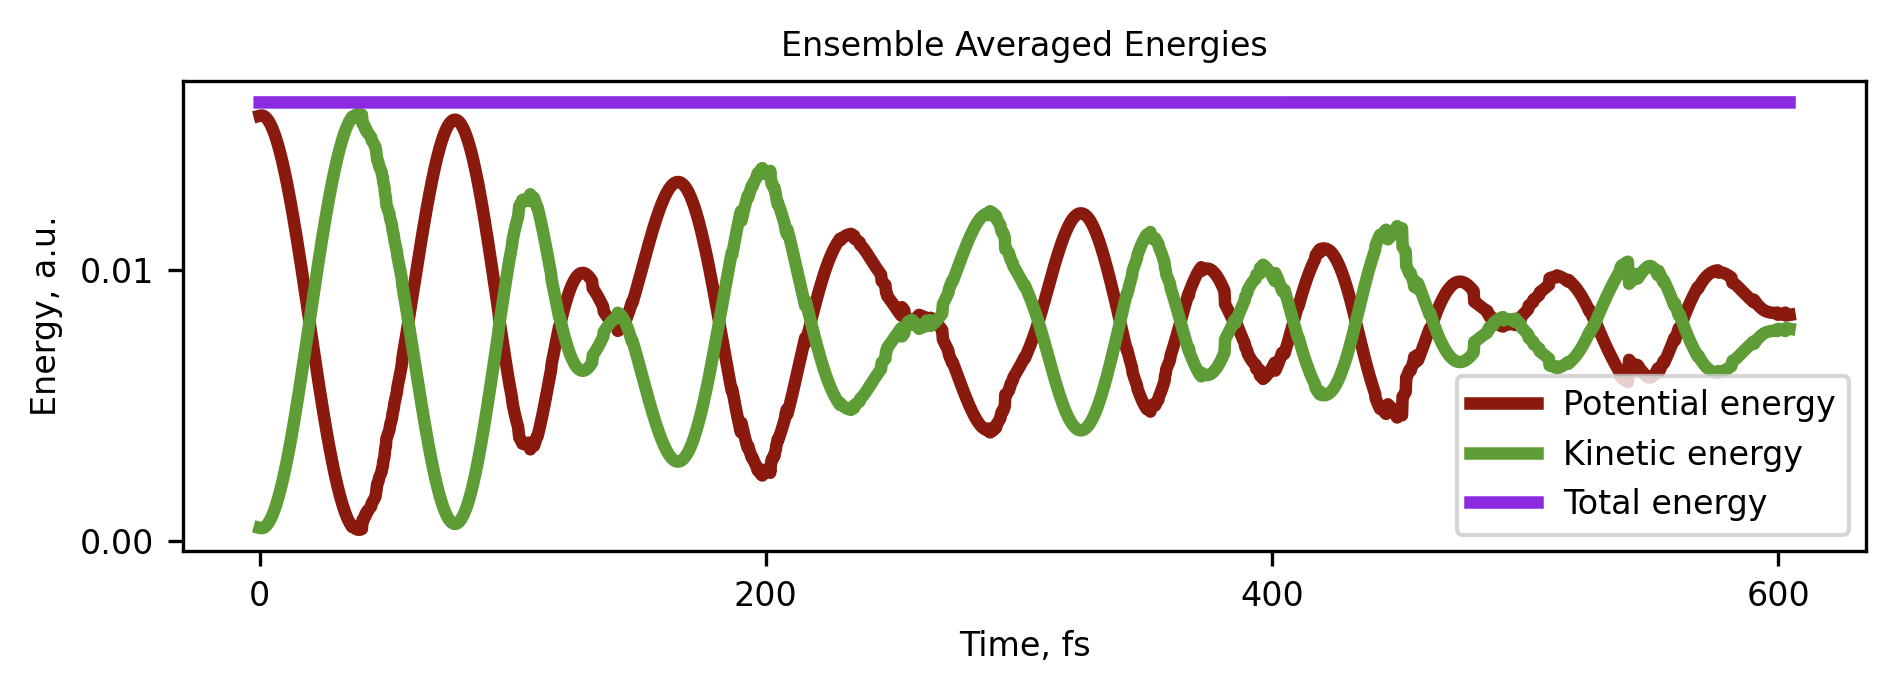

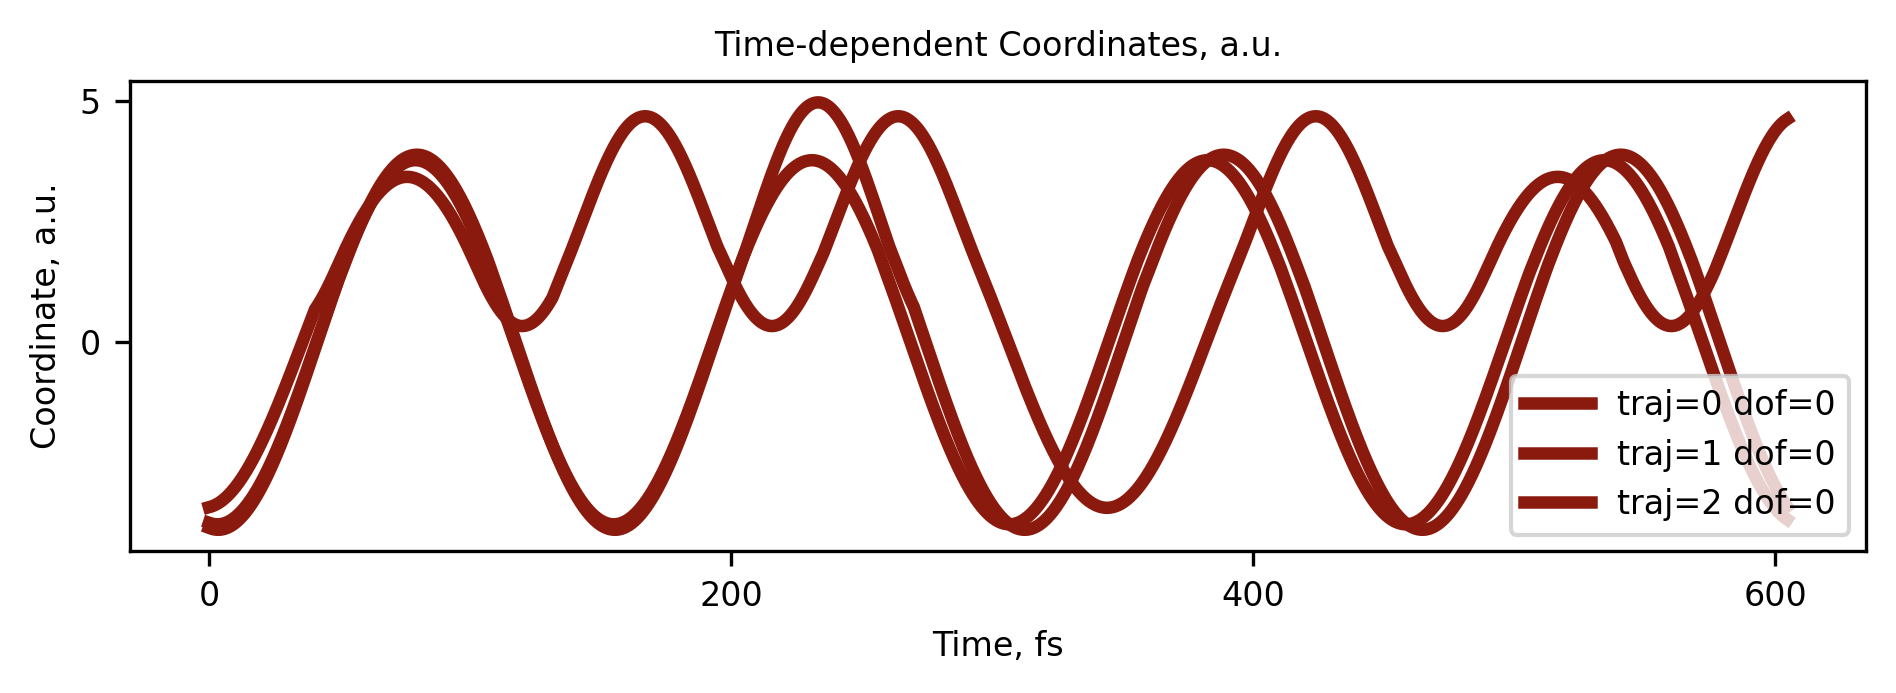

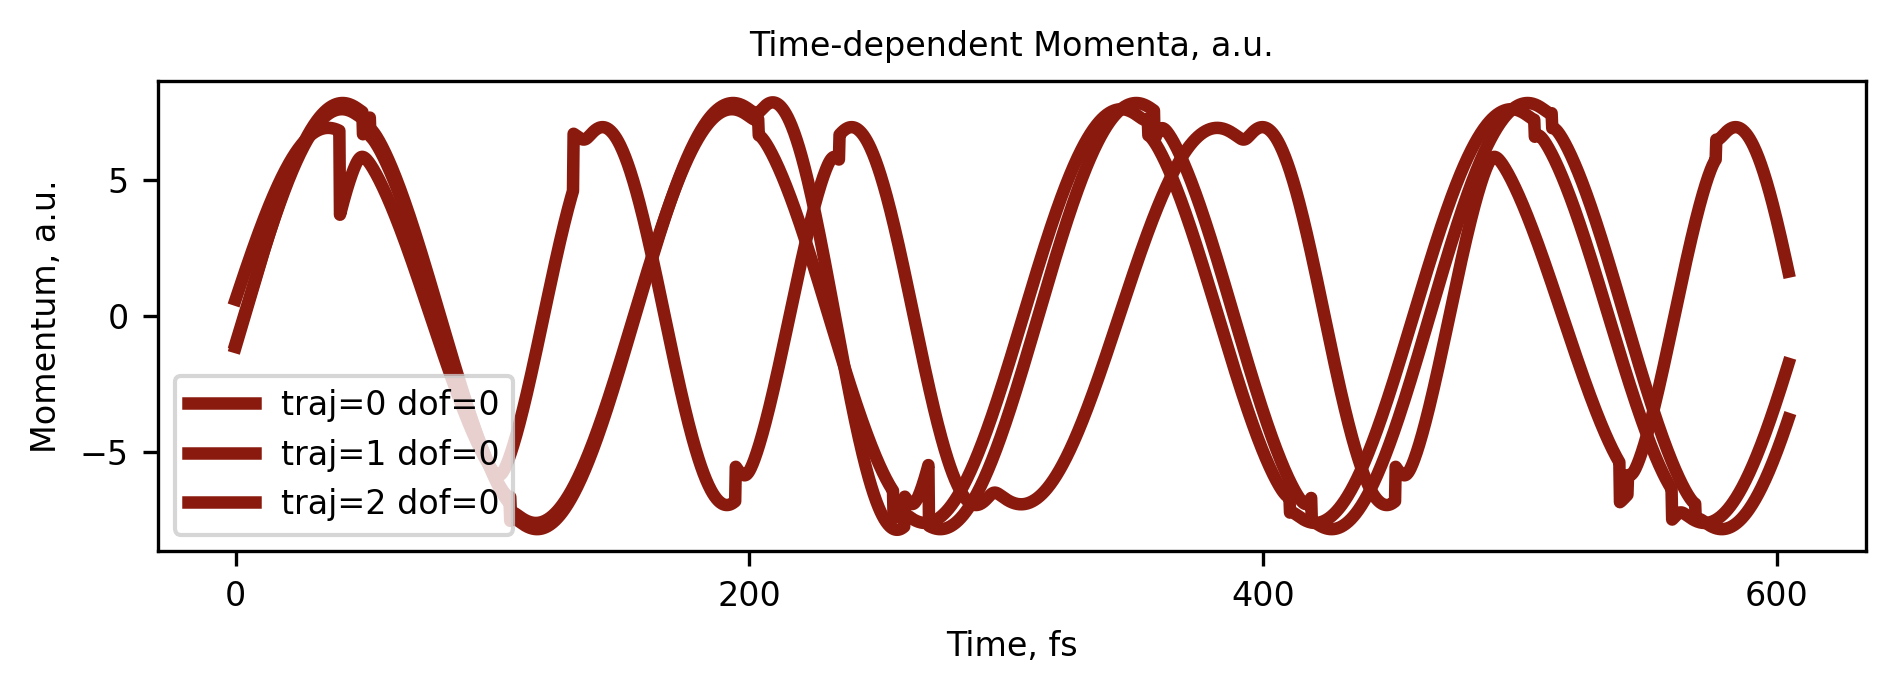

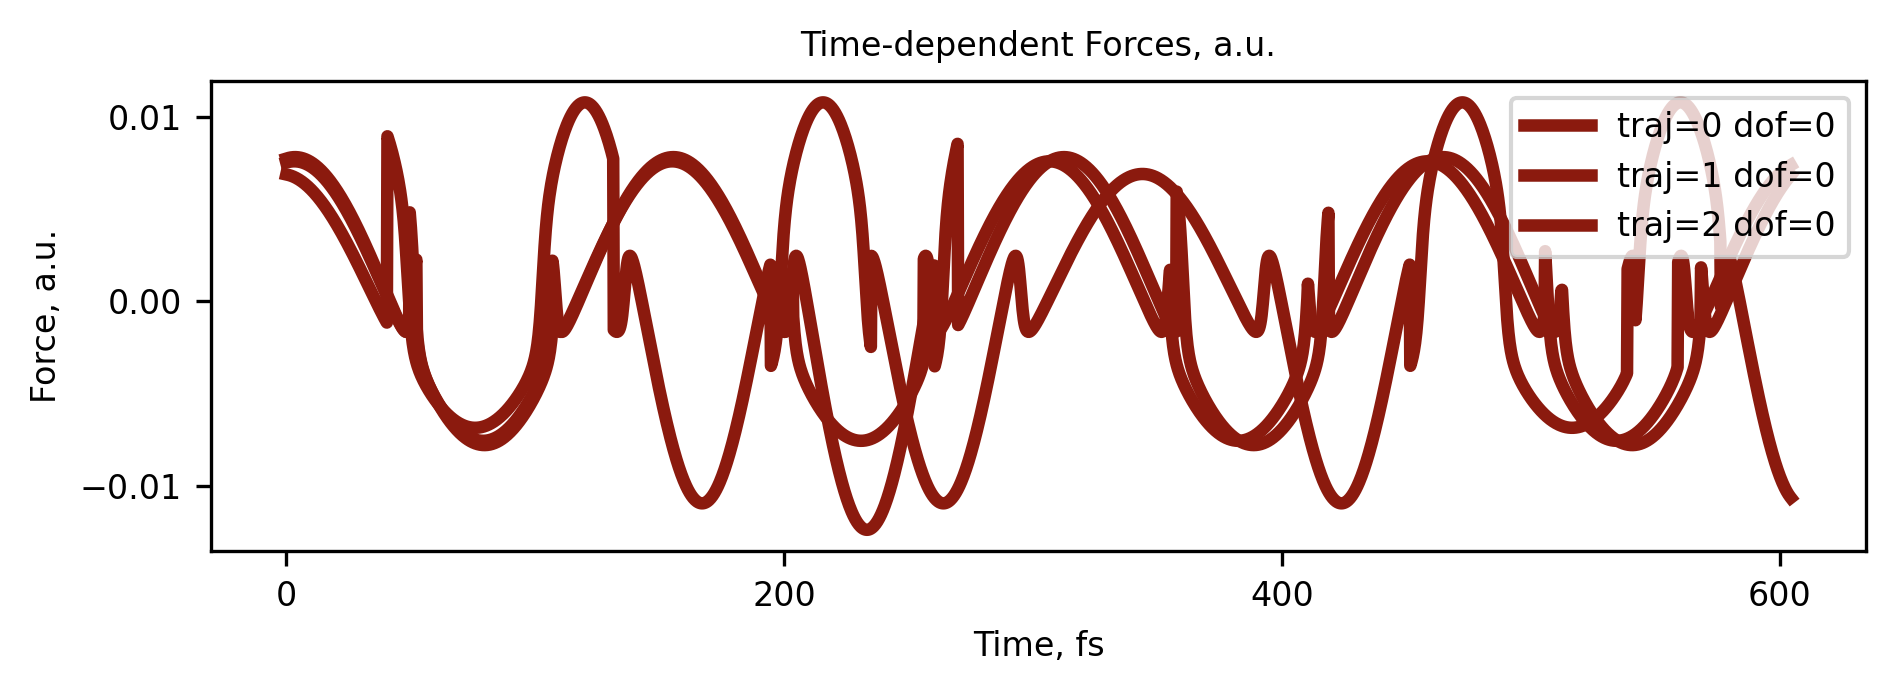

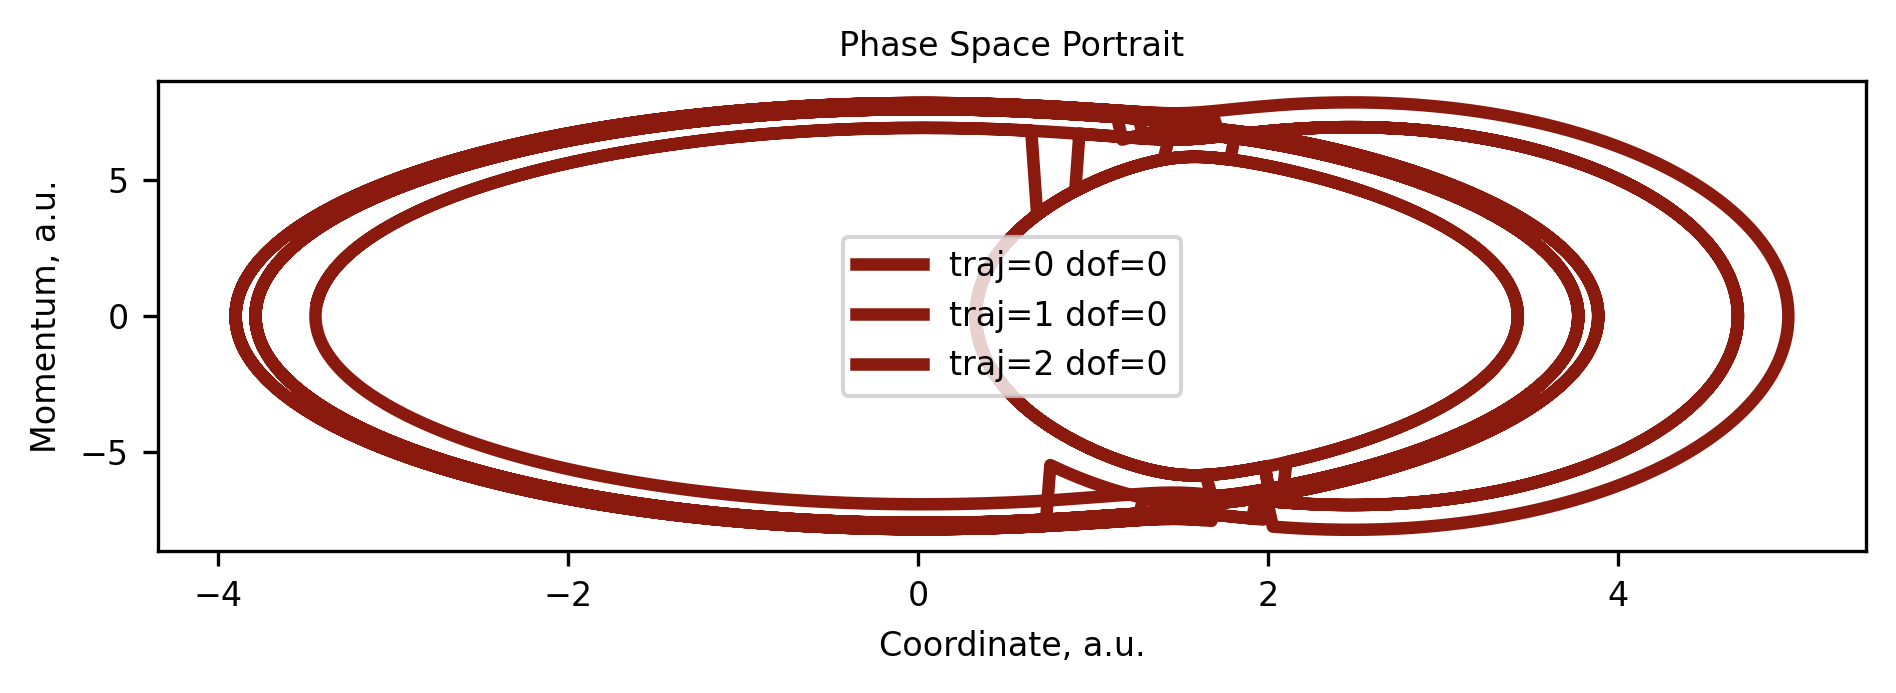

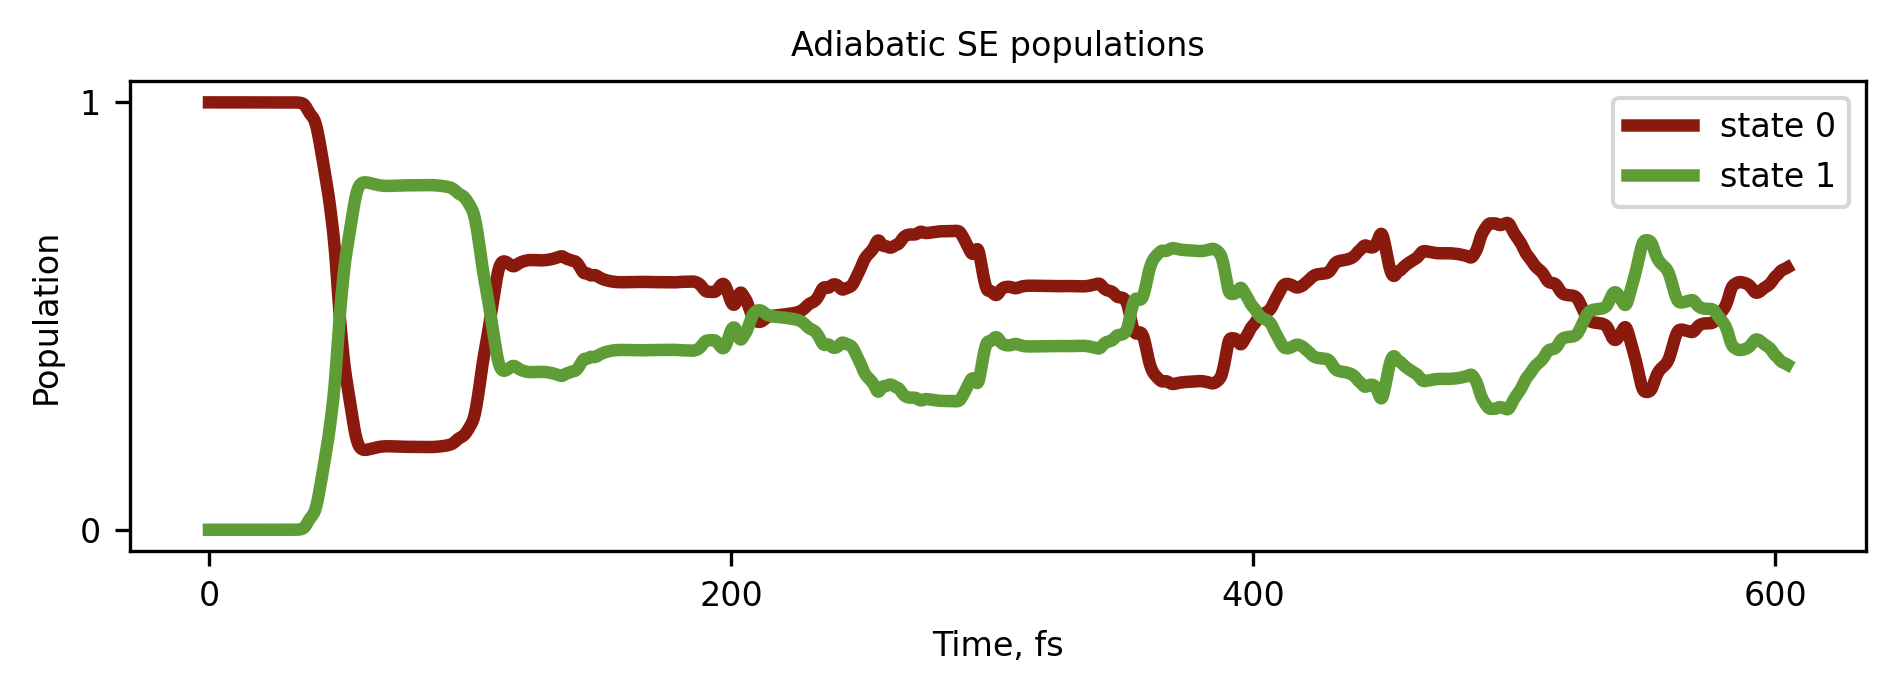

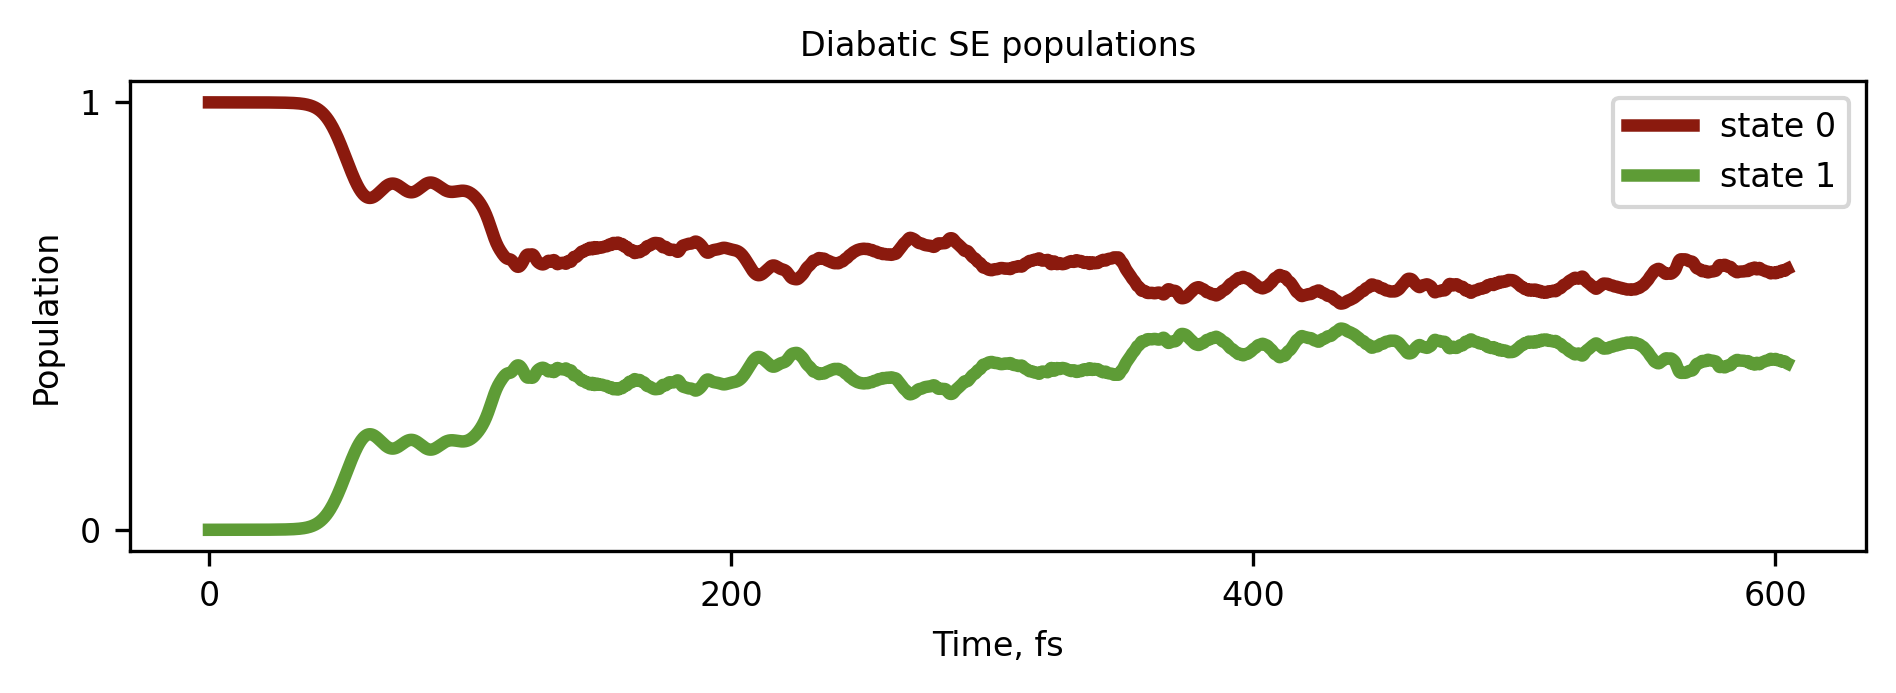

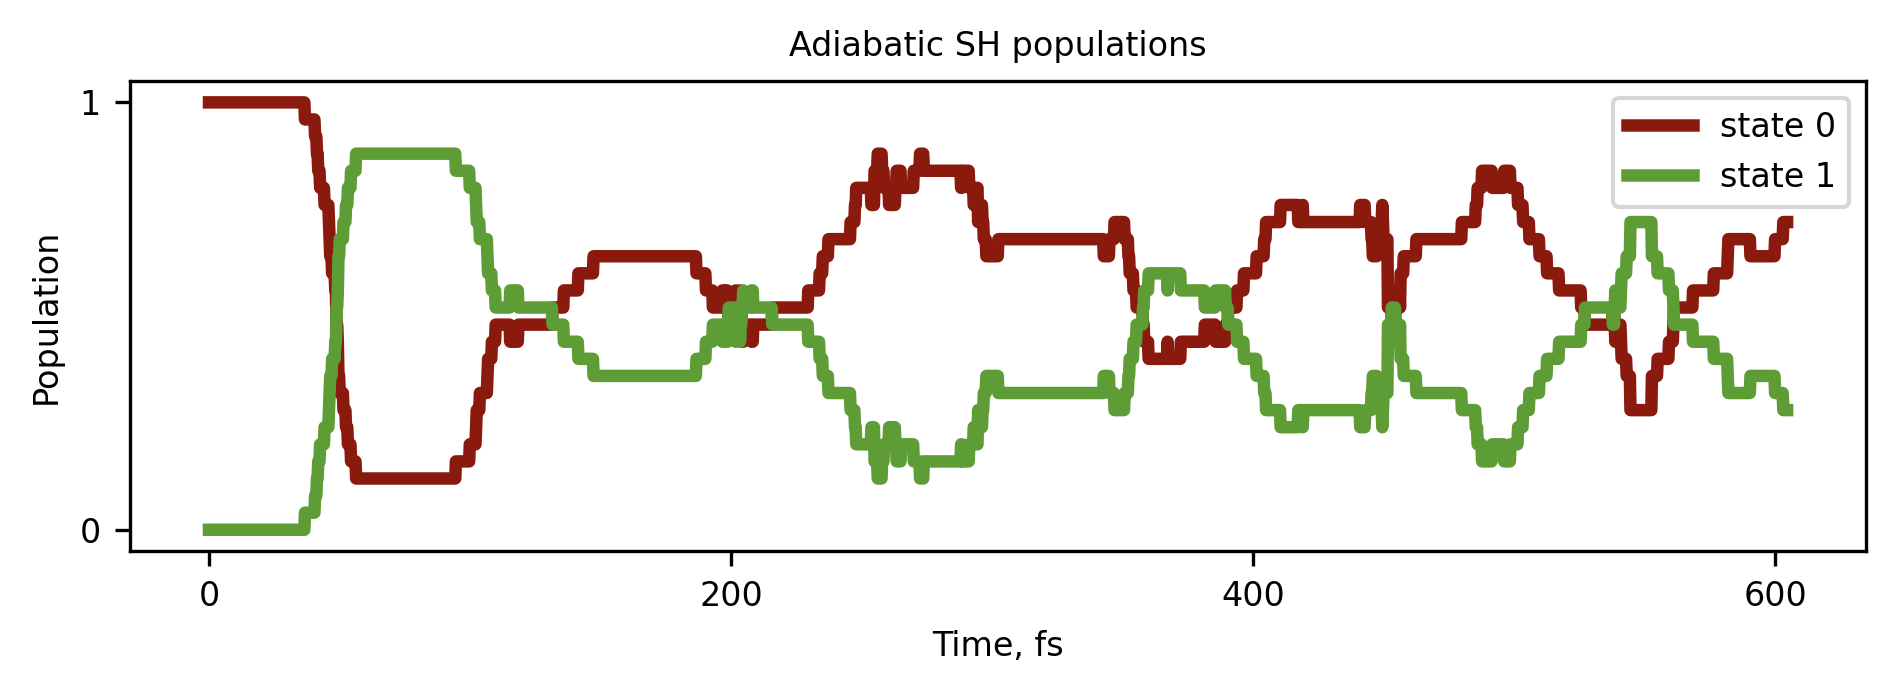

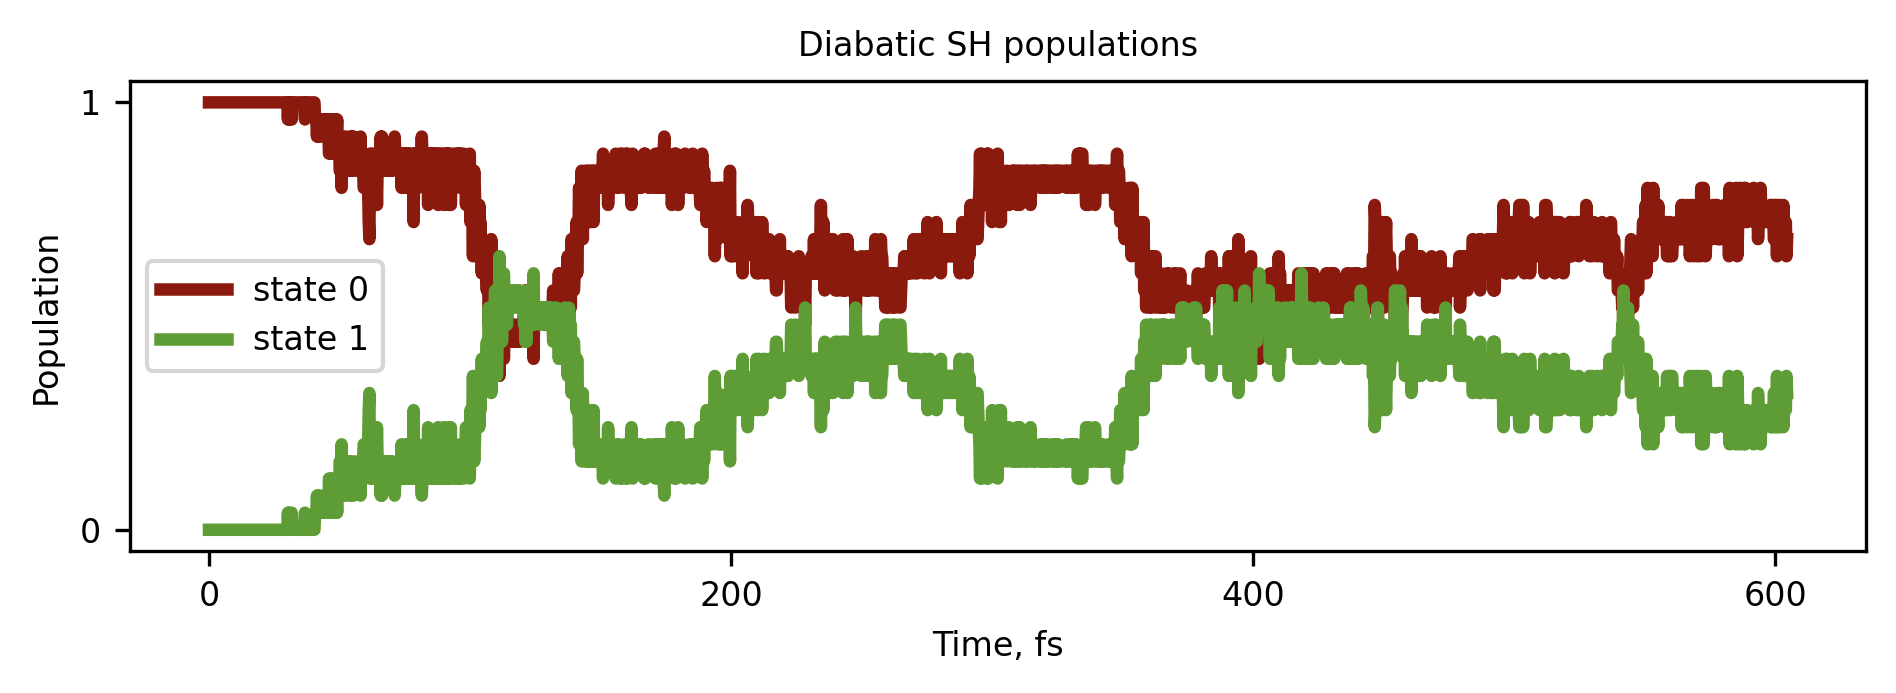

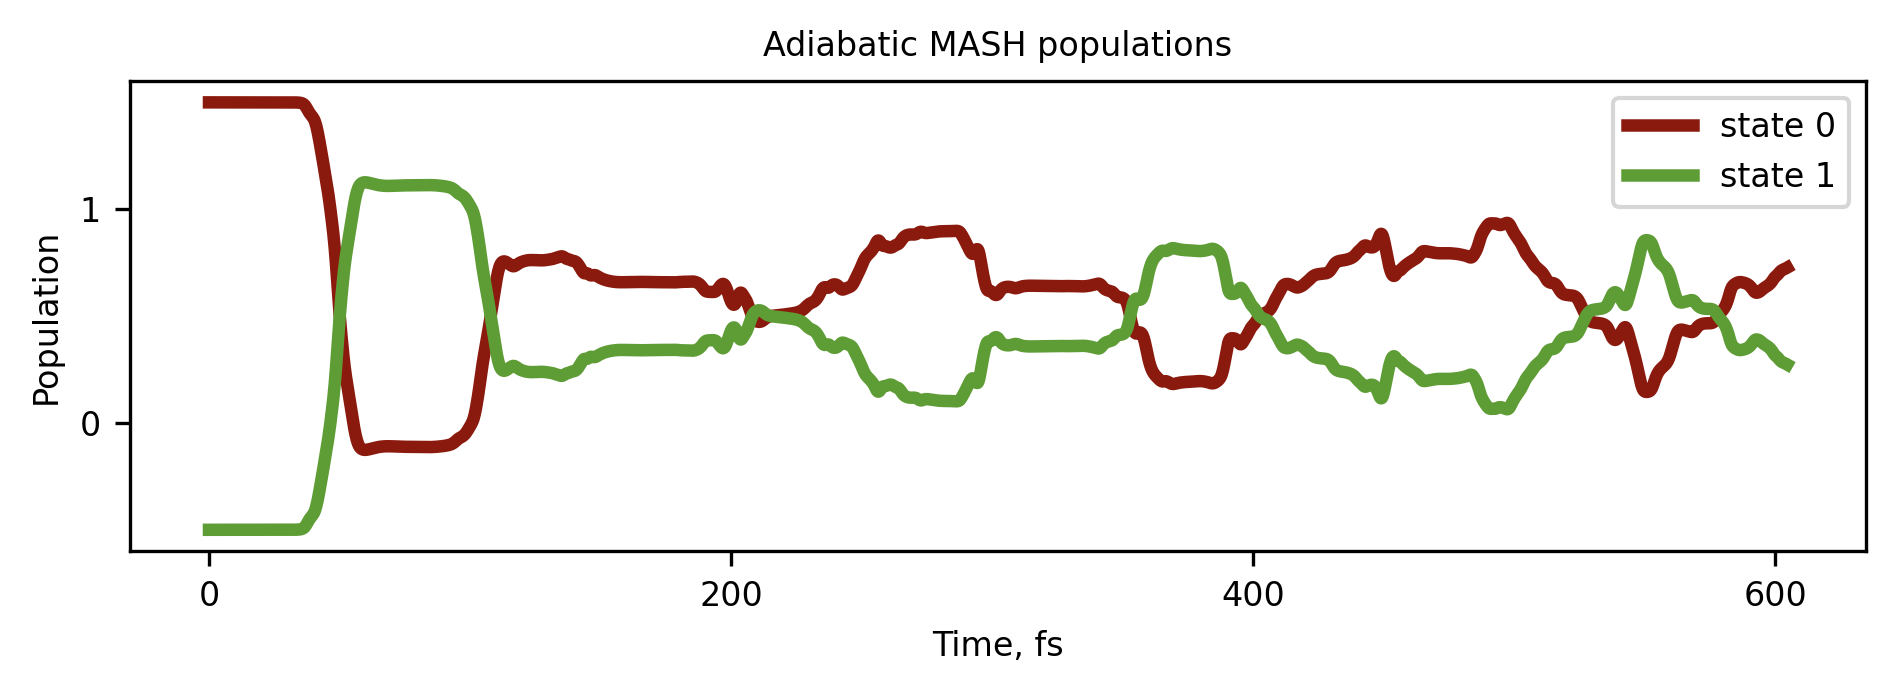

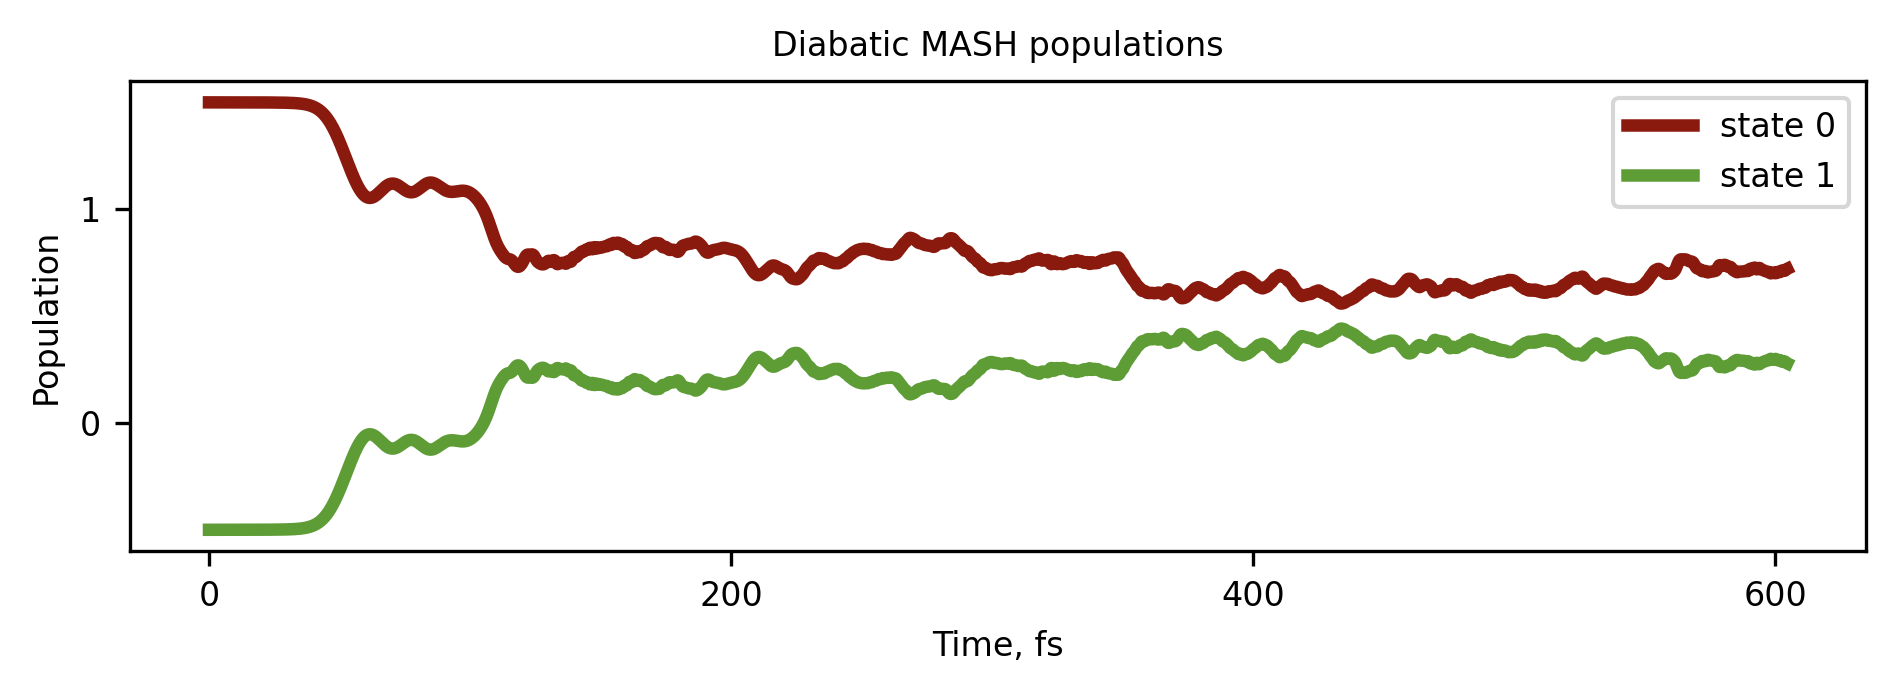

In [13]:
#============ Plotting ==================
pref = F"model{model_indx}-method{method_indx}-variant_{suff}-param{param_indx}-icond_type{icond_type_indx}-icond{icond_indx}"

plot_params = { "prefix":pref, "filename":"mem_data.hdf", "output_level":3,
                "which_trajectories":[0, 1, 2], "which_dofs":[0], "which_adi_states":list(range(NSTATES)), 
                "which_dia_states":list(range(NSTATES)), 
                "frameon":True, "linewidth":3, "dpi":300,
                "axes_label_fontsize":(8,8), "legend_fontsize":8, "axes_fontsize":(8,8), "title_fontsize":8,
                "what_to_plot":["coordinates", "momenta",  "forces", "energies", "phase_space", "se_pop_adi",
                                "se_pop_dia", "sh_pop_adi", "sh_pop_dia", "mash_pop_adi", "mash_pop_dia" ], 
                "which_energies":["potential", "kinetic", "total"],
                "save_figures":1, "do_show":1
              }

#"what_to_plot":["coordinates", "momenta",  "forces", "energies", "phase_space", "se_pop_adi",
#                                "se_pop_dia", "sh_pop_adi", "traj_resolved_adiabatic_ham", "traj_resolved_diabatic_ham", 
#                                "time_overlaps", "basis_transform"
#                               ], 

tsh_dynamics_plot.plot_dynamics(plot_params)